# RQ1 factor B - retrieval strategy

**What varies:** how candidate segments are scored, four levels.
**What is held constant:** 512-unit sliding-window segments with 10% overlap, no reranking,
candidate depth 20, context depth 5, all 910 questions.

**The centre point.** Every notebook varies one factor and holds the rest at 512-unit sliding
window segments with 10% overlap, BGE-small dense retrieval, no reranking, candidate depth 20
and context depth 5. That is what makes each measurement a *main effect*: no arm differs from
the centre in two ways at once.

**Levels**

| Level | Scoring |
|---|---|
| BM25 | k1 = 1.5, b = 0.75, non-negative IDF, corpus-wide document frequencies |
| dense *(centre point)* | BGE-small cosine similarity |
| hybrid RRF | reciprocal rank fusion of the two lists, k = 60 |
| hybrid weighted | 0.5 x z-scored dense + 0.5 x z-scored BM25 |

Because the two hybrids are built from exactly the same BM25 and dense lists, any difference
between them is the fusion rule alone.

**Runtime:** about 6 minutes, most of it building the BM25 index once.

## 1. Open the shared cache

In [1]:
# Load the shared library written by notebook 00 and open the same cache.
import sys, os
from google.colab import drive
drive.mount('/content/drive')
PROJECT = '/content/drive/MyDrive/techqa_rq1'
assert os.path.exists(PROJECT + '/rq1_core.py'), (
    'rq1_core.py not found. Run RQ1_00_Build_Once.ipynb first - it writes the library '
    'and builds the chunk tables and embeddings that this notebook reads from cache.')
sys.path.insert(0, PROJECT)
import rq1_core as C
import numpy as np, pandas as pd, time, json
C.setup(project_dir=PROJECT)
print('GPU:', C.gpu_name())

Mounted at /content/drive
rq1_core 1.2 | profile=fast | run tag u512_o10_p0
  cache   -> /content/drive/MyDrive/techqa_rq1/cache_u512_o10_p0
  outputs -> /content/drive/MyDrive/techqa_rq1/outputs_u512_o10_p0
GPU: Tesla T4


In [2]:
# The whole labelled dataset, on the fast local disk.
# Notebook 00 mirrors the four extracted files to Drive, so this fresh runtime restores them
# with a file copy (~1 min) instead of re-downloading and re-extracting the archive (~5 min).
# getattr() keeps this working whichever build of notebook 00 wrote the library to Drive.
if not C.dataset_present():
    if getattr(C, 'dataset_mirrored', lambda: False)():
        print('restoring the corpus from the Drive mirror ...')
        C.restore_dataset_from_mirror()
    else:
        dl, ex = C.download_commands()
        get_ipython().system(dl)
        get_ipython().system(ex)
        if hasattr(C, 'mirror_dataset'):
            C.mirror_dataset()
ds = C.load_dataset()
print(json.dumps(ds.summary(), indent=1))

restoring the corpus from the Drive mirror ...
{
 "questions": 910,
 "answerable": 610,
 "unanswerable": 300,
 "per_split": {
  "train": [
   600,
   450
  ],
  "dev": [
   310,
   160
  ]
 },
 "technotes": 28482,
 "candidate_technotes": 28461
}


## 2. Every retrieval strategy at the centre-point segmentation

In [3]:
idx = C.load_method_index(ds, C.CFG.BASELINE_METHOD, with_bm25=True)
print(f"{len(idx.table):,} chunks | BM25 index built in "
      f"{idx.timings['bm25_index_s']:.0f}s, {idx.bm25.memory_mb():.0f} MB, "
      f"{len(idx.bm25.vocab):,} terms")

38,046 chunks | BM25 index built in 8s, 48 MB, 368,938 terms


In [4]:
frames, contexts, cost = [], {}, []
for r in C.CFG.RETRIEVERS:
    t0 = time.perf_counter()
    df, latency = C.run_arm(idx, ds.questions, retriever=r, arm_name=r)
    contexts[r] = {q['QUESTION_ID']: C.top_context(idx, q, r).tolist() for q in ds.questions}
    frames.append(df)
    cost.append({'retriever': r, 'retrieval_ms': latency * 1000,
                 'whole_matrix_s': time.perf_counter() - t0,
                 'index_mb': idx.bm25.memory_mb() if 'bm25' in r or 'hybrid' in r
                             else idx.emb.nbytes / 1024**2})
    print(f'{r:<18} {len(df):>4} questions   {latency*1000:7.2f} ms/query')

B = pd.concat(frames, ignore_index=True)
cost_B = pd.DataFrame(cost)
json.dump(contexts, open(C.PATHS.CACHE / 'contexts_factorB.json', 'w'))
C.save_table(B, 'rq1_factorB_per_question')

bm25                610 questions      0.86 ms/query
dense               610 questions      0.04 ms/query
hybrid_rrf          610 questions      0.94 ms/query
hybrid_weighted     610 questions      1.29 ms/query
  saved /content/drive/MyDrive/techqa_rq1/outputs_u512_o10_p0/rq1_factorB_per_question.csv


PosixPath('/content/drive/MyDrive/techqa_rq1/outputs_u512_o10_p0/rq1_factorB_per_question.csv')

### Reproduction check against Table 5.2

The dissertation's retrieval matrix ran BM25 and BGE-small dense on the 450 answerable **training** questions at this exact configuration. Restricting this run the same way should land on those numbers; a large gap means the segmenter or the query construction has drifted.

In [5]:
train = B[B.split == 'train']
prior = {'bm25':  {'Recall@20': 0.7000, 'gold_span_coverage': 0.5618, 'MRR': 0.4736,
                   'nDCG@5': 0.4878},
         'dense': {'Recall@20': 0.8067, 'gold_span_coverage': 0.6307, 'MRR': 0.5619,
                   'nDCG@5': 0.5736}}
rows = []
for arm, ref in prior.items():
    sub = train[train.retriever == arm]
    for k, v in ref.items():
        rows.append({'arm': arm, 'metric': k, 'this_run': sub[k].mean(),
                     'Table_5.2': v, 'difference': sub[k].mean() - v, 'n': len(sub)})
repro = pd.DataFrame(rows)
display(repro.round(4))
C.save_table(repro, 'rq1_factorB_reproduction_check')
print('\nDifferences within about 0.02 are the expected effect of implementation detail;'
      '\nanything larger should be investigated before the numbers are reported.')

,arm,metric,this_run,Table_5.2,difference,n
0,bm25,Recall@20,0.7000,0.7000,0.0000,450
1,bm25,gold_span_coverage,0.5595,0.5618,-0.0023,450
2,bm25,MRR,0.4774,0.4736,0.0038,450
3,bm25,nDCG@5,0.4899,0.4878,0.0021,450
4,dense,Recall@20,0.8067,0.8067,-0.0000,450
5,dense,gold_span_coverage,0.6307,0.6307,-0.0000,450
6,dense,MRR,0.5600,0.5619,-0.0019,450
7,dense,nDCG@5,0.5723,0.5736,-0.0013,450


  saved /content/drive/MyDrive/techqa_rq1/outputs_u512_o10_p0/rq1_factorB_reproduction_check.csv

Differences within about 0.02 are the expected effect of implementation detail;
anything larger should be investigated before the numbers are reported.


## 3. The metric profile per strategy

,retriever,n,nDCG@5,Recall@20,MRR,gold_span_coverage,context_precision@5,context_recall@5,gold_document_in_top_5,chunk_boundary_loss
0,bm25,610,0.4987,0.7213,0.4827,0.5780,0.1170,0.5780,0.5902,0.0148
1,dense,610,0.5693,0.8246,0.5530,0.6436,0.1298,0.6436,0.6672,0.0262
2,hybrid_rrf,610,0.5429,0.8262,0.5318,0.6165,0.1236,0.6165,0.6328,0.0197
3,hybrid_weighted,610,0.5726,0.8033,0.5559,0.6476,0.1308,0.6476,0.6623,0.0180


  saved /content/drive/MyDrive/techqa_rq1/outputs_u512_o10_p0/rq1_factorB_summary.csv
  figure -> /content/drive/MyDrive/techqa_rq1/outputs_u512_o10_p0/figures/fig_rq1_factorB_profile.png


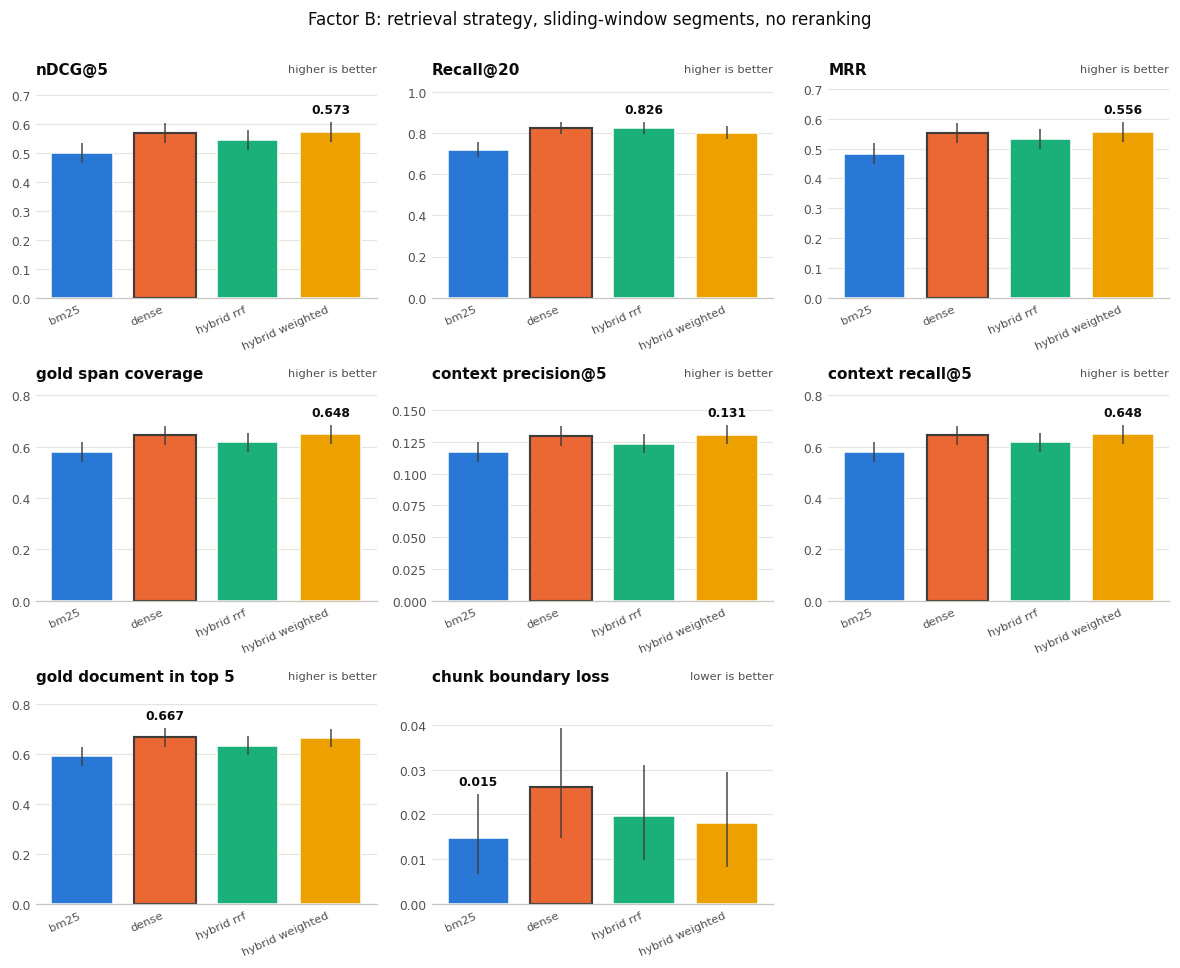

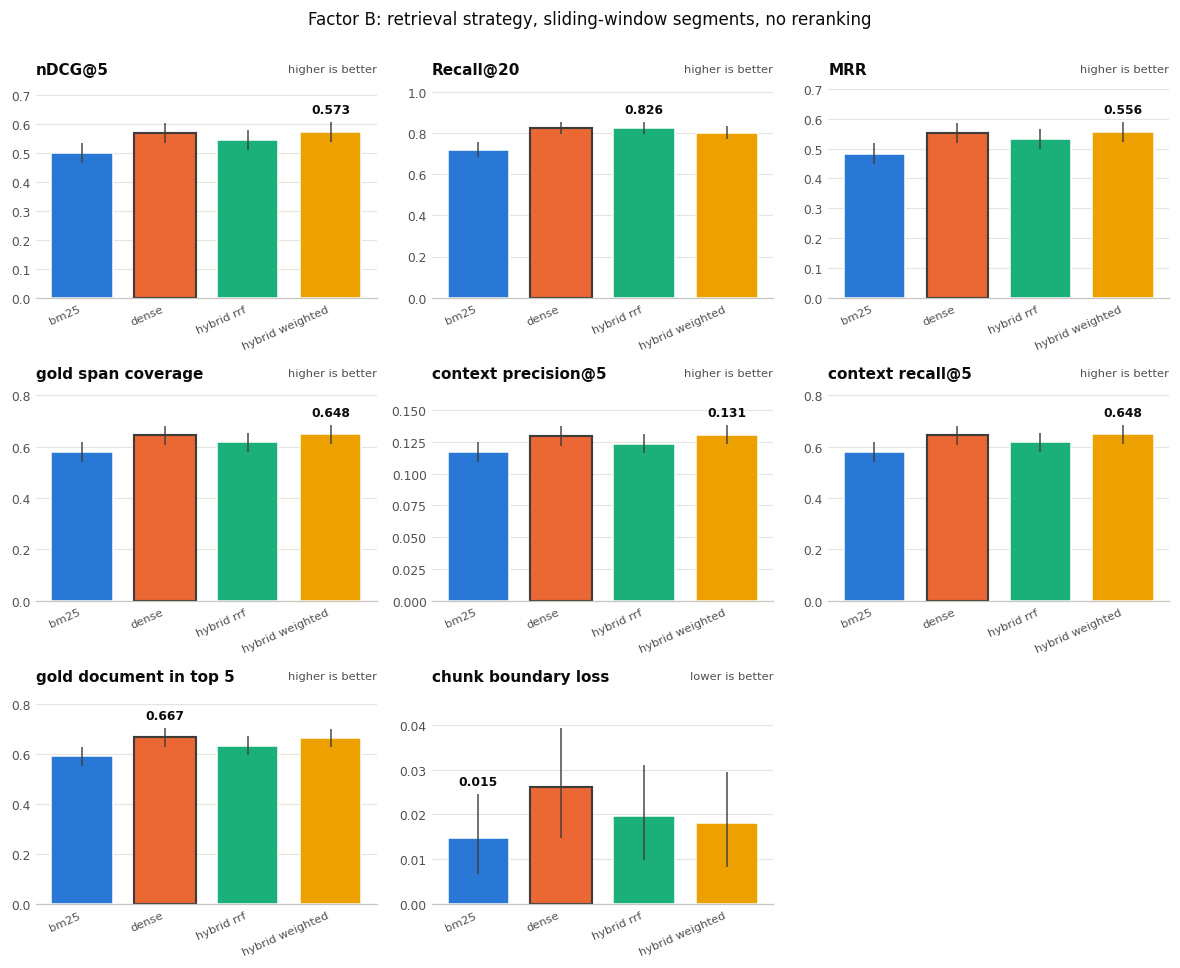

In [6]:
METRICS = C.RETRIEVAL_METRICS
summary_B = C.arm_summary(B, ['retriever'], METRICS)
summary_B['retriever'] = pd.Categorical(summary_B['retriever'],
                                        categories=C.CFG.RETRIEVERS, ordered=True)
summary_B = summary_B.sort_values('retriever')
display(summary_B[['retriever', 'n'] + METRICS].round(4))
C.save_table(summary_B, 'rq1_factorB_summary')
C.plot_metric_bars(summary_B, 'retriever', METRICS,
    'Factor B: retrieval strategy, sliding-window segments, no reranking',
    'fig_rq1_factorB_profile', baseline=C.CFG.BASELINE_RETRIEVER,
    caption='Retrieval-evidence profile of four retrieval strategies over all 610 answerable '
            'TechQA questions at 512-unit sliding-window segmentation without reranking. '
            'Error bars are 95% bootstrap intervals over questions.')

## 4. Contrasts against dense retrieval

,level,level_mean,baseline_mean,mean_diff,lo,hi,p_holm,significant,n
0,bm25,0.4987,0.5693,-0.0706,-0.1046,-0.0355,0.0000,True,610
1,hybrid_rrf,0.5429,0.5693,-0.0264,-0.0528,-0.0005,0.0936,False,610
2,hybrid_weighted,0.5726,0.5693,0.0033,-0.0226,0.0287,0.7948,False,610


  saved /content/drive/MyDrive/techqa_rq1/outputs_u512_o10_p0/rq1_factorB_contrasts.csv
  figure -> /content/drive/MyDrive/techqa_rq1/outputs_u512_o10_p0/figures/fig_rq1_factorB_forest.png

bm25 against dense gives a mean difference of -0.0706 in nDCG@5, with a 95% interval from -0.1046 to -0.0355 over 610 paired questions. The interval excludes zero.

hybrid rrf against dense gives a mean difference of -0.0264 in nDCG@5, with a 95% interval from -0.0528 to -0.0005 over 610 paired questions. The interval excludes zero.

hybrid weighted against dense gives a mean difference of +0.0033 in nDCG@5, with a 95% interval from -0.0226 to +0.0287 over 610 paired questions. The interval includes zero, so the difference is not resolved at this sample size.


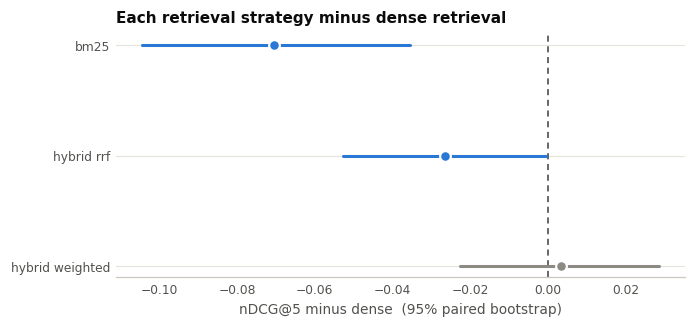

In [7]:
contrasts_B = C.pairwise_against_baseline(B, 'retriever', C.CFG.BASELINE_RETRIEVER, METRICS)
display(contrasts_B[contrasts_B.metric == 'nDCG@5'][
    ['level', 'level_mean', 'baseline_mean', 'mean_diff', 'lo', 'hi', 'p_holm',
     'significant', 'n']].round(4))
C.save_table(contrasts_B, 'rq1_factorB_contrasts')
C.plot_forest(contrasts_B, 'nDCG@5', 'Each retrieval strategy minus dense retrieval',
    'fig_rq1_factorB_forest',
    caption='Paired bootstrap 95% intervals for nDCG@5 of each retrieval strategy minus dense '
            'retrieval. Grey intervals cross zero.')
for _, r in contrasts_B[contrasts_B.metric == 'nDCG@5'].iterrows():
    print('\n' + C.describe_contrast(r))

## 5. Where the strategies disagree

The vocabulary-mismatch argument of Section 2.4 predicts that BM25 and dense retrieval fail on *different* questions. If that holds, the ceiling for fusion is higher than either alone, and the gap between the fusion result and that ceiling measures how much the fusion rule is leaving on the table.

In [8]:
w = C.to_wide(B, 'gold_document_in_top_5', 'retriever')
both = float(((w.bm25 > 0) & (w.dense > 0)).mean())
only_b = float(((w.bm25 > 0) & (w.dense == 0)).mean())
only_d = float(((w.bm25 == 0) & (w.dense > 0)).mean())
neither = float(((w.bm25 == 0) & (w.dense == 0)).mean())
oracle = both + only_b + only_d
fused = float((w['hybrid_rrf'] > 0).mean())
overlap = {'both_succeed': both, 'bm25_only': only_b, 'dense_only': only_d,
           'neither': neither, 'union_ceiling': oracle, 'hybrid_rrf_achieved': fused,
           'headroom_left_by_fusion': oracle - fused, 'n_questions': int(len(w))}
print(json.dumps(overlap, indent=1))
C.save_results(overlap, 'rq1_factorB_complementarity')

{
 "both_succeed": 0.5065573770491804,
 "bm25_only": 0.08360655737704918,
 "dense_only": 0.16065573770491803,
 "neither": 0.24918032786885247,
 "union_ceiling": 0.7508196721311475,
 "hybrid_rrf_achieved": 0.6327868852459017,
 "headroom_left_by_fusion": 0.11803278688524588,
 "n_questions": 610
}
  saved /content/drive/MyDrive/techqa_rq1/outputs_u512_o10_p0/rq1_factorB_complementarity.json


PosixPath('/content/drive/MyDrive/techqa_rq1/outputs_u512_o10_p0/rq1_factorB_complementarity.json')

## 6. Cost, and what factor B contributes to RQ1

In [9]:
display(cost_B.round(2))
C.save_table(cost_B, 'rq1_factorB_cost')
eff_B = C.repeated_measures_effect(C.to_wide(B, 'nDCG@5', 'retriever'))
C.save_results({'effect_nDCG@5': eff_B, 'summary': summary_B.to_dict(orient='records'),
                'complementarity': overlap,
                'provenance': C.stamp({'factor': 'retrieval_strategy'})}, 'rq1_factorB')
print(f"Retrieval strategy, nDCG@5: levels span {eff_B['range']:.4f} "
      f"(95% CI {eff_B['range_lo']:.4f} to {eff_B['range_hi']:.4f}), "
      f"partial eta-squared {eff_B['eta2_partial']:.4f}, best level {eff_B['best_level']}.")
print('\nFactor B complete. Run RQ1_C_Reranking.ipynb next.')

,retriever,retrieval_ms,whole_matrix_s,index_mb
0,bm25,0.86,1.34,48.11
1,dense,0.04,0.09,55.73
2,hybrid_rrf,0.94,1.64,48.11
3,hybrid_weighted,1.29,1.99,48.11


  saved /content/drive/MyDrive/techqa_rq1/outputs_u512_o10_p0/rq1_factorB_cost.csv
  saved /content/drive/MyDrive/techqa_rq1/outputs_u512_o10_p0/rq1_factorB.json
Retrieval strategy, nDCG@5: levels span 0.0739 (95% CI 0.0539 to 0.1051), partial eta-squared 0.0245, best level hybrid_weighted.

Factor B complete. Run RQ1_C_Reranking.ipynb next.


## Worked example behind each result

Every table and figure above is an average over hundreds of questions. The cells below take **one real question** through the same calculation, so the reader can see how a single row becomes the number that is reported. Nothing is recomputed: the values are read back from the files this notebook wrote.

In [10]:
%%writefile /content/drive/MyDrive/techqa_rq1/example_cases.py
"""
example_cases.py - one real worked example behind every result and every figure.

Each function takes a single question (or a single answer) from the saved result files and
walks it through the calculation the surrounding table or figure aggregates, so a reader can
see how one row becomes the number that is reported. Nothing here computes a new result: every
value is read back from the files the notebooks wrote.

    chunking_example      what each chunking method leaves of one question's gold span
    retrieval_example     one question under the four retrievers
    reranking_example     one question with and without the cross-encoder
    effects_example       one main-effect contrast, recomputed from the paired column
    generation_example    one generated answer, its citations and its correctness check
    attribution_example   one question through the four stage tests, in pipeline order
    prompt_example        the same question under both prompts, with its stage label fixed
    certainty_example     one question's signals, its cross-fitted score and its band
    citation_example      one answer's citation pattern and the band it earns
    rq1_scenario          RQ1 answered from a single question
    rq2_scenario          RQ2 answered from a single question
    rq3_scenario          RQ3 answered from the two ends of the certainty scale

Every function prints a short block and returns the row it used, so a notebook cell can show
the example directly under the result it explains.

    import example_cases as EX
    EX.chunking_example(RESULTS)
"""
from __future__ import annotations

from pathlib import Path

import pandas as pd

WIDTH = 78
CENTRE_METHOD = "sliding_window"


def _rule(title):
    print("\n" + "-" * WIDTH)
    print(f"WORKED EXAMPLE  |  {title}")
    print("-" * WIDTH)


def _read(results, name):
    p = Path(results) / name
    if not p.exists():
        raise FileNotFoundError(f"{p} is missing; run the notebook that writes it first")
    return pd.read_csv(p)


def _pick(frame, prefer=None):
    """A stable choice: the named question if present, else the first by identifier."""
    if prefer is not None and (frame.question_id == prefer).any():
        return prefer
    return sorted(frame.question_id.unique())[0]


# ---------------------------------------------------------------------------------
# RQ1: the three factors
# ---------------------------------------------------------------------------------

def chunking_example(results, question_id=None):
    """One question seen by all five chunking methods, with the centre point first."""
    f = _read(results, "rq1_factorA_per_question.csv")
    # a question the methods disagree about makes the sharpest example, chosen over the four
    # methods that share BGE-small so the difference is segmentation and not the encoder
    same_encoder = f[~f.method.isin(["late_chunking", "sliding_window_longctx"])]
    spread = (same_encoder.groupby("question_id").gold_span_coverage
              .agg(lambda s: s.max() - s.min()).sort_values(ascending=False))
    qid = question_id or (spread.index[0] if len(spread) else _pick(f))
    rows = f[f.question_id == qid].set_index("method")
    _rule(f"chunking method, question {qid}")
    print("How much of this question's gold span each segmentation leaves in the context,")
    print("with the same retriever and the same context depth:\n")
    for method in rows.index:
        r = rows.loc[method]
        print(f"  {method:<24} coverage {float(r.gold_span_coverage):.3f}   "
              f"nDCG@5 {float(r['nDCG@5']):.3f}   "
              f"gold document in context: {'yes' if float(r.gold_document_in_top_5) else 'no'}")
    best, worst = rows.gold_span_coverage.idxmax(), rows.gold_span_coverage.idxmin()
    print(f"\n  The spread on this one question, {float(rows.gold_span_coverage.max()):.3f} under "
          f"{best} against\n  {float(rows.gold_span_coverage.min()):.3f} under {worst}, is one "
          "row of the average the table reports.")
    return rows


def retrieval_example(results, question_id=None):
    f = _read(results, "rq1_factorB_per_question.csv")
    qid = question_id or _pick(f)
    rows = f[f.question_id == qid].set_index("retriever")
    _rule(f"retrieval strategy, question {qid}")
    print("The same question and the same segmentation, scored by each retriever:\n")
    for r_ in rows.index:
        r = rows.loc[r_]
        rank = r.gold_doc_rank
        print(f"  {r_:<18} gold document rank {('-' if pd.isna(rank) else int(rank)):>3}   "
              f"Recall@20 {float(r['Recall@20']):.0f}   coverage {float(r.gold_span_coverage):.3f}")
    print("\n  Recall@20 counts only whether the document arrived; coverage says how much of")
    print("  the answer came with it, which is why both are reported.")
    return rows


def reranking_example(results, question_id=None):
    f = _read(results, "rq1_factorC_per_question.csv")
    changed = f.pivot_table(index="question_id", columns="rerank_level",
                            values="gold_span_coverage", aggfunc="first").dropna()
    if {"off", "cross_encoder"} <= set(changed.columns):
        moved = changed[changed.off != changed.cross_encoder]
        qid = question_id or (moved.index[0] if len(moved) else _pick(f))
    else:
        qid = question_id or _pick(f)
    rows = f[f.question_id == qid].set_index("rerank_level")
    _rule(f"reranking, question {qid}")
    print("The candidate list is identical; only the order in which it is cut to five differs:\n")
    for level in rows.index:
        r = rows.loc[level]
        print(f"  reranking {level:<14} gold document in context: "
              f"{'yes' if float(r.gold_document_in_top_5) else 'no ':<3}   "
              f"coverage {float(r.gold_span_coverage):.3f}   "
              f"context precision {float(r['context_precision@5']):.3f}")
    return rows


def effects_example(results, measure="gold_span_coverage", level="semantic_breakpoint"):
    """The contrast behind one cell of the main-effects table, recomputed from the rows."""
    f = _read(results, "rq1_factorA_per_question.csv")
    a = f[f.method == CENTRE_METHOD].set_index("question_id")[measure]
    b = f[f.method == level].set_index("question_id")[measure]
    both = pd.concat([a.rename("centre"), b.rename("level")], axis=1).dropna()
    diff = both.level - both.centre
    _rule(f"main effect, {level} against the centre point on {measure}")
    print(f"  questions paired            {len(both)}")
    print(f"  mean under {CENTRE_METHOD:<16} {both.centre.mean():.4f}")
    print(f"  mean under {level:<16} {both.level.mean():.4f}")
    print(f"  paired difference           {diff.mean():+.4f}")
    print(f"  questions worse / unchanged / better  "
          f"{int((diff < 0).sum())} / {int((diff == 0).sum())} / {int((diff > 0).sum())}")
    worst = diff.idxmin()
    print(f"\n  The largest single loss is {worst}: {both.loc[worst, 'centre']:.3f} -> "
          f"{both.loc[worst, 'level']:.3f}.")
    print("  The table reports the mean of this column with a bootstrap interval; the figure")
    print("  plots it. This is the column itself.")
    return both


# ---------------------------------------------------------------------------------
# generation and attribution
# ---------------------------------------------------------------------------------

def generation_example(results, answers="rq1_generation_answers.csv",
                       scored="rq1_generation_scored.csv", config_id=None, question_id=None,
                       chars=420):
    """One generated answer: what it cited, what it scored and whether the check passed."""
    a = _read(results, answers)
    s = _read(results, scored)
    cfg = config_id or sorted(a.config_id.unique())[0]
    sub = a[(a.config_id == cfg) & a.answerable.astype(str).str.lower().isin(["true", "1"])]
    qid = question_id or _pick(sub)
    row = sub[sub.question_id == qid].iloc[0]
    sc = s[(s.question_id == qid) & (s.config_id == cfg)]
    _rule(f"one generated answer, question {qid}, configuration {cfg}")
    print(f"  segments given to the model : {row.segment_ids}")
    text = str(row.answer).strip().replace("\n", "\n    ")
    print(f"  answer:\n    {text[:chars]}{'...' if len(text) > chars else ''}")
    if len(sc):
        r = sc.iloc[0]
        print(f"\n  cited segments {int(r.n_cited)}   groundedness {float(r.groundedness):.3f}   "
              f"faithfulness {float(r.faithfulness):.3f}")
        print(f"  token F1 {float(r.token_f1):.3f}   abstained: "
              f"{'yes' if bool(r.abstained) else 'no'}")
        print(f"  the correctness check of Section 5.6 passes at token F1 >= 0.15, so this "
              f"answer {'passes' if float(r.token_f1) >= 0.15 else 'fails'}.")
    return row


def attribution_example(results, question_id=None, configuration=None, threshold=0.80):
    """One question walked through the four tests, in the order the pipeline runs them."""
    import rq2_core as R2
    frames = R2.load_traces(results)
    ceiling = R2.load_ceiling(results)
    table, _ = R2.configuration_table(frames, ceiling)
    cfg = configuration or R2.CENTRE
    sub = table[table.configuration == cfg]
    stages = R2.attribute(sub, threshold)
    qid = question_id or _pick(sub[stages.values != "R"]) if (stages.values != "R").any() \
        else _pick(sub)
    row = sub[sub.question_id == qid].iloc[0]
    stage = R2.attribute(sub[sub.question_id == qid], threshold).iloc[0]
    ceil = float(row[R2.CEILING])
    in20 = str(row.gold_document_in_top_20).lower() in ("1", "1.0", "true", "yes")
    in5 = str(row.gold_document_in_top_5).lower() in ("1", "1.0", "true", "yes")
    cov = float(row.gold_span_coverage)
    _rule(f"stage attribution, question {qid}, {cfg}")
    tests = [
        ("1  does the segmentation still allow 80% of the span?",
         f"ceiling {ceil:.3f}", ceil >= threshold, "S1 segmentation loss"),
        ("2  is the gold Technote among the top-20 candidates?",
         "yes" if in20 else "no", in20, "S2 retrieval miss"),
        ("3  do the chosen segments carry 80% of the span?",
         f"in context: {'yes' if in5 else 'no'}, coverage {cov:.3f}",
         in5 and cov >= threshold, "S3 context exclusion"),
    ]
    for label, observed, passed, fail_label in tests:
        mark = "pass" if passed else "FAIL"
        print(f"  {label:<52} {observed:<28} {mark}")
        if not passed:
            print(f"\n  -> {fail_label}. No test below this one is read.")
            break
    else:
        print(f"  {'4  the evidence was delivered':<52} {'reachable':<28} pass")
        print("\n  -> any failure here is S4 generation drift, which needs a judged answer.")
    print(f"\n  the rule returns: {stage}")
    return row


def prompt_example(results, question_id=None):
    """The same question under both prompts, with every stage label unchanged."""
    o = _read(Path(results) / "rq2", "rq2_generation_outcomes.csv")
    sub = o[o.configuration == o.configuration.iloc[0]]
    qid = question_id or _pick(sub)
    row = sub[sub.question_id == qid].iloc[0]
    _rule(f"prompt comparison, question {qid}")
    print(f"  attributed stage : {row.stage}   (identical under both prompts: retrieval did "
          "not change)")
    print(f"  second run       : abstained {bool(row.abstained)}, correct {bool(row.correct)}, "
          f"outcome {row.outcome}")
    print("\n  Figure 5.12 aggregates exactly this: the stage label is fixed by retrieval, and")
    print("  only the answer column moves when the prompt changes.")
    return row


# ---------------------------------------------------------------------------------
# RQ3: certainty
# ---------------------------------------------------------------------------------

def certainty_example(rq3_dir, question_id=None, split="dev"):
    """One question's signals, the score they produce and the band it lands in."""
    import json
    import rq3_core as R3
    sig = _read(rq3_dir, "rq3_signals.csv")
    res = json.loads((Path(rq3_dir) / "rq3_results.json").read_text(encoding="utf-8"))
    features = res["features"]
    scores = R3.cross_fitted_scores(sig, features)
    sub = sig[sig.split == split]
    qid = question_id or _pick(sub)
    row = sig[sig.question_id == qid].iloc[0]
    p = float(scores.loc[scores.question_id == qid, "score"].iloc[0])
    band = next(b for c, b in zip(list(R3.BAND_CUTS) + [1.01], R3.BANDS) if p < c)
    _rule(f"certainty score, question {qid} ({split} split)")
    print("  the signals a deployed system could compute for this question:")
    for f in features:
        print(f"    {R3.SIGNAL_NAMES.get(f, f):<38} {float(row[f]):+.4f}")
    print(f"\n  score from the model fitted on the other split : {p:.3f}")
    print(f"  band                                           : {band}")
    print(f"  what actually happened                         : evidence "
          f"{'reached' if float(row.label_evidence) else 'did not reach'} the generator")
    print("  (which stage blocked it is RQ2's rule, not this score's: see attribution_example)")
    return row


def citation_example(rq3_dir, band="high"):
    """One answer's citation pattern, the band it earns and whether it passed the check."""
    path = Path(rq3_dir) / "rq3_citation_test_answers.csv"
    if not path.exists():
        _rule("citation band")
        print("  The out-of-sample citation test has not been run in this workspace, so there")
        print("  is no answer to show. It needs notebook D's answers; run the cell headed")
        print("  'The citation rule on answers it was not derived from' above, then this one.")
        return None
    a = _read(rq3_dir, "rq3_citation_test_answers.csv")
    sub = a[a.band == band]
    row = sub.iloc[0]
    _rule(f"citation band, one {band}-band answer")
    print(f"  question {row.question_id}, configuration {row.config_id}")
    print(f"  cited segments {int(row.n_cited)}   cites the top-ranked document: "
          f"{'yes' if bool(row.cites_top_document) else 'no'}   abstained: "
          f"{'yes' if bool(row.abstained) else 'no'}")
    print(f"  -> band {row.band}")
    print(f"  token F1 {float(row.token_f1):.3f}, so the correctness check "
          f"{'passes' if bool(row.correct) else 'fails'}.")
    print("\n  Table 5.15 counts these outcomes band by band over the 150 questions the rule")
    print("  was not derived from.")
    return row


# ---------------------------------------------------------------------------------
# One scenario per research question: a single question, followed from end to end, so the
# answer to the question can be read off a case instead of an average.
# ---------------------------------------------------------------------------------

def rq1_scenario(results, question_id=None):
    """RQ1: which component decides whether the evidence arrives?"""
    f = _read(results, "rq1_factorA_per_question.csv")
    b = _read(results, "rq1_factorB_per_question.csv")
    same_encoder = f[~f.method.isin(["late_chunking", "sliding_window_longctx"])]
    spread = (same_encoder.groupby("question_id").gold_span_coverage
              .agg(lambda s: s.max() - s.min()).sort_values(ascending=False))
    qid = question_id or spread.index[0]
    ch = same_encoder[same_encoder.question_id == qid].set_index("method")
    re_ = b[b.question_id == qid].set_index("retriever")
    _rule(f"RQ1 scenario: question {qid}")
    print("RQ1 asks which component most decides the quality of the evidence the generator\n"
          "receives. Watch one question travel the pipeline twice.\n")
    print("  Changing the SEGMENTATION, retriever fixed:")
    for m in ch.index:
        print(f"    {m:<24} the context holds {float(ch.loc[m].gold_span_coverage):.0%} "
              f"of the gold answer")
    print("\n  Changing the RETRIEVER, segmentation fixed:")
    for r_ in re_.index:
        rank = re_.loc[r_].gold_doc_rank
        print(f"    {r_:<24} gold document rank "
              f"{'not retrieved' if pd.isna(rank) else int(rank):<14} "
              f"context holds {float(re_.loc[r_].gold_span_coverage):.0%}")
    print("\n  Read together: the retriever decides whether the right Technote arrives at all,")
    print("  and the segmentation decides how much of the answer arrives with it. That is the")
    print("  split Section 5.5 reports over all 610 questions, and why RQ1 is answered by a")
    print("  division of labour rather than by a single winning component.")
    return ch


def rq2_scenario(results, question_id=None, configuration=None):
    """RQ2: what does a stage label say that an aggregate score cannot?"""
    import rq2_core as R2
    frames = R2.load_traces(results)
    ceiling = R2.load_ceiling(results)
    table, _ = R2.configuration_table(frames, ceiling)
    cfg = configuration or R2.CENTRE
    sub = table[table.configuration == cfg].reset_index(drop=True)
    stages = R2.attribute(sub)
    blocked = sub[stages.values != "R"]
    qid = question_id or _pick(blocked if len(blocked) else sub)
    _rule(f"RQ2 scenario: question {qid}, {cfg}")
    print("RQ2 asks whether a failed answer can be blamed on one stage, and whether that\n"
          "changes what an engineer would do next.\n")
    attribution_example(results, question_id=qid, configuration=cfg)
    shares = stages.value_counts(normalize=True)
    reach = float(shares.get("R", 0.0))
    print(f"\n  An aggregate score would record one more wrong answer and stop there. The rule")
    print(f"  says which stage owes the fix, and counting the labels over all "
          f"{len(sub)} questions")
    print(f"  puts a ceiling on the generator: {reach:.1%} of questions have their evidence")
    print(f"  delivered, so no change to the model alone can do better than that.")
    return sub


def rq3_scenario(rq3_dir, question_id=None):
    """RQ3: can the system tell, without gold labels, when to trust its own answer?"""
    _rule("RQ3 scenario: two questions, one trustworthy and one not")
    print("RQ3 asks whether signals available at query time can sort answers into bands that\n"
          "mean something. Here are the two ends of the scale.\n")
    import json
    import rq3_core as R3
    sig = _read(rq3_dir, "rq3_signals.csv")
    res = json.loads((Path(rq3_dir) / "rq3_results.json").read_text(encoding="utf-8"))
    scores = R3.cross_fitted_scores(sig, res["features"]).set_index("question_id")
    dev = sig[sig.split == "dev"].copy()
    dev["score"] = scores.reindex(dev.question_id).score.to_numpy()
    top = dev.sort_values("score").dropna(subset=["score"])
    for label, row in (("lowest score", top.iloc[0]), ("highest score", top.iloc[-1])):
        band = next(b for c, b in zip(list(R3.BAND_CUTS) + [1.01], R3.BANDS)
                    if float(row.score) < c)
        print(f"  {label:<14} question {row.question_id}: score {float(row.score):.2f} "
              f"-> band {band}")
        print(f"    top segment stands {float(row.dense_z_top1):+.1f} SD above the rest of the "
              f"pool; dense and lexical retrieval agree on "
              f"{float(row.agree_top5):.0%} of the context")
        print(f"    what actually happened: the evidence "
              f"{'reached' if float(row.label_evidence) else 'did not reach'} the generator\n")
    print("  The band is computed with no gold annotation, which is what makes it usable by a")
    print("  system that has none: it decides when to answer and when to hold back. Section 5.7")
    print("  reports how often that decision is right on questions the model never saw.")
    return dev


ALL = {"chunking": chunking_example, "retrieval": retrieval_example,
       "reranking": reranking_example, "effects": effects_example,
       "generation": generation_example, "attribution": attribution_example,
       "prompt": prompt_example, "certainty": certainty_example,
       "citation": citation_example, "rq1": rq1_scenario, "rq2": rq2_scenario,
       "rq3": rq3_scenario}


Overwriting /content/drive/MyDrive/techqa_rq1/example_cases.py


In [11]:
import sys, importlib
if '/content/drive/MyDrive/techqa_rq1' not in sys.path:
    sys.path.insert(0, '/content/drive/MyDrive/techqa_rq1')
import example_cases as EX
EX = importlib.reload(EX)

In [12]:
_ = EX.retrieval_example(C.PATHS.OUT)


------------------------------------------------------------------------------
WORKED EXAMPLE  |  retrieval strategy, question DEV_Q000
------------------------------------------------------------------------------
The same question and the same segmentation, scored by each retriever:

  bm25               gold document rank   -   Recall@20 0   coverage 0.000
  dense              gold document rank  19   Recall@20 1   coverage 0.000
  hybrid_rrf         gold document rank   -   Recall@20 0   coverage 0.000
  hybrid_weighted    gold document rank  20   Recall@20 1   coverage 0.000

  Recall@20 counts only whether the document arrived; coverage says how much of
  the answer came with it, which is why both are reported.
